# 全局配置
 安装docker，在docker里安装milvus，在docker中选用以下源<br>
  "registry-mirrors": [<br>
    "https://docker.m.daocloud.io",<br>
    "https://dockerhub.timeweb.cloud",<br>
    "https://docker.1panel.live"<br>
  ]<br>
  <br>
依赖安装<br>
uv pip install pymilvus  <br>
uv pip install notebook  <br>

# milvus数据模型
Database:Milvus的数据库,用来隔离不同业务数据。<br>
Collection:集合，最核心的逻辑容器,类似于关系型数据库里的table 表，本质上就是一个多列的表，且其中的每个字段按列存储：<br>
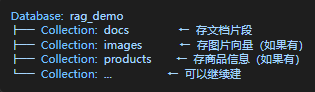<br>
Partition:分区,是collection的子集,不是必须手动创建;一个collection至少会有默认partition。<br>
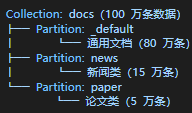<br>
Entity:可以理解为collection中的一条记录。类似于关系型数据库的一行数据。<br>
<br>
在传统数据库中,如果你想存储用户信息,你会建一张表叫user_table;想存储商品,会建一张表叫 product_table。<br>
在向量数据库中,我们要存储的是成千上万个“特征向量”以及它们对应的文本。为了把不同用途的向量分门别类地存放,我们就要创建不同的Collection。比如,COLLECTION_NAME="docs"就是给这张“表”取名叫docs,专门用来存放你切分好的文档片段向量。<br>

# 基本用法
## 向量数据库相关操作

In [ ]:
#操作客户端
from pymilvus import MilvusClient
#默认端口号为19530
client=MilvusClient("http://localhost:19530")

### 列出所有数据库

In [ ]:
existed_databases = client.list_databases()
for x in existed_databases:
    print(x)

### 创建数据库

In [ ]:
#创建之前检测存不存在
db_name ="rag_demo"
if db_name not in existed_databases:
    client.create_database(db_name="rag_demo")

### 删除数据库
如果数据库下有Collection则无法删除,需要先删除它的所有Collection才能删除Database

In [ ]:
#删除不需要检测存不存在
client.drop_database("rag_demo")

## collection相关操作

### 切换当下操作的数据库

In [ ]:
#当下操作的是rag_damo数据库
client.use_database(db_name="rag_demo")

### 查看数据库下的collection

In [ ]:
collection=client.list_collections()
for x in collection:
    print(x)

### 创建collection
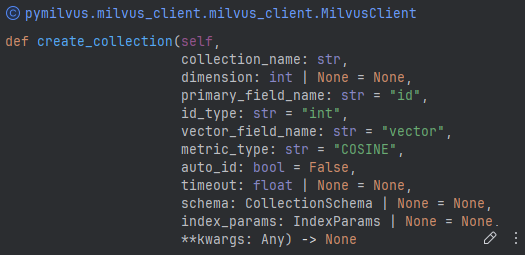

In [ ]:
collection_name = "docs"
#创建collection时，会自动生成一个空partition，不指定就往里插入数据就会默认进_default
client.create_collection(
    collection_name=collection_name,#名称
    dimension=1024,#向量维度，与嵌入模型有关，嵌入模型embedding的是1024维，这里就填1024
    metric_type="COSINE"#如何判断两个向量间的相似度，cosine表示余弦相似度，越接近1二者越相关，必须是大写，否则会报错
)

### 删除collection
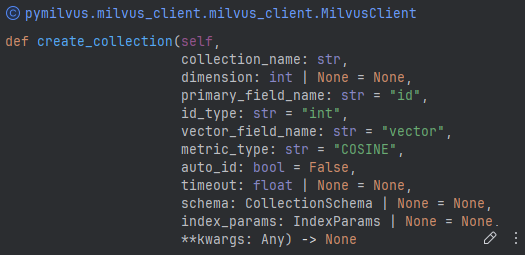

In [ ]:
client.drop_collection(collection_name=collection_name)

## 嵌入模型相关操作


### 嵌入模型的初始化

uv pip install python-dotenv<br>
uv pip install langchain<br>
uv pip install langchain-openai

In [ ]:
#环境变量的配置
from dotenv import load_dotenv
load_dotenv()

In [ ]:
# from langchain.embeddings import init_embeddings
# import os
# #初始化嵌入模型
# #把百炼当成一个OpenAI兼容服务来调走的是通用OpenAI协议，需要手动传 api_key 和 base_url，依赖包：langchain-openai
# #init_embeddings通过model参数的"openai:"前缀自动识别底层要用OpenAIEmbeddings，所以不需要手动from langchain_openai import OpenAIEmbeddings，它内部会动态加载,但是必须uv pip install langchain-openai
#
# #换模型更加方便，只需替换名称，key以及url，openai不用换，已经适配了，但其输入列表与百炼的输入列表格式可能对不上，可能会报错，它把 OpenAI 格式的 input（纯数组 ["text1","text2"]）误解析成了它自己的多维嵌套结构 input.contents，导致参数校验失败。此时调用百炼原生接口
#
# embed_model = init_embeddings(
#     model="openai:text-embedding-v4",  # 阿里云百炼 embedding 模型
#     api_key=os.getenv("DASHSCOPE_API_KEY"),
#     base_url=os.getenv("DASHSCOPE_BASE_URL")
# )

In [ ]:
# #本质上就是调用openai
# #uv pip install langchain.openai
# from langchain_openai import OpenAIEmbeddings
# embed_model = OpenAIEmbeddings(
#     model="text-embedding-v2",  # 阿里云百炼 embedding 模型
#     api_key=os.getenv("DASHSCOPE_API_KEY"),
#     base_url=os.getenv("DASHSCOPE_BASE_URL")
# )

In [ ]:
#另外一个方法，调的百炼原生接口，由阿里官方 SDK 封装自动，从环境变量 DASHSCOPE_API_KEY 读取密钥，不用手动传依赖包：langchain-community（内部封装了 dashscope SDK）

#需要uv pip install langchain_community与uv pip install dashscope
from langchain_community.embeddings import DashScopeEmbeddings
from dotenv import load_dotenv

# 加载 .env 中的环境变量
load_dotenv()

# 创建 DashScope Embeddings 实例
embed_model = DashScopeEmbeddings(
    model="text-embedding-v4",  # 阿里云百炼 embedding 模型
)

### 嵌入模型中句子的向量化与存入数据库
uv pip install rich

In [ ]:
from rich import print as rprint

#rich是一个让终端输出更好看的库,输出json格式更好看

#查看collection的元数据,是一个json格式的数据，3.2.3中创建了 "docs" ，collection_name = "docs"
metadata = client.describe_collection(collection_name=collection_name)

rprint(metadata)

In [ ]:
#准备原始数据，此处为文本型
texts = [
"LangChain 是一个用于构建 LLM应用的开发框架",
"Milvus 是一个适合 AI 应用的向量数据库",
"RAG 的核心是先检索相关知识,再让大模型生成答案",
"Docker Desktop 可以方便地在本地运行 Milvus Standalone"
]

In [ ]:
#生成嵌入向量
vectors = embed_model.embed_documents(texts)

In [ ]:
#容器内有多少个向量
print(len(vectors))
#每个向量多少维
print(len(vectors[0]))
#第一个向量中前五个维度的向量是多少
print(vectors[0][:5])

In [ ]:
#embed_model.embed_documents()返回的本身就是列表，client.upsert() 要求的参数是实体列表，每条实体必须是一个 dict字典，包含当时建 Collection 时定义的所有字段，vectors中只有向量，这一步是为了拼接

data = [
    {
        #向量对应的id
        "id":i,
        #嵌入向量
        "vector":vectors[i],
        #向量对应的文本
        "text":texts[i],
        #来源
        "source":"demo"
    }
    for i in range(len(texts))
]
#Python 列表推导式语法：[表达式 for 变量 in 可迭代对象]，把"你想要什么"放在前面，把"从哪来"放在后面，读起来更接近自然语言，如果还要加条件过滤for依然在后面，if再往后放， if len(texts[i]) > 10 ，只保留文本长度大于10

#Python 通过缩进来决定代码块的范围：if 条件为 True → 执行它下面所有缩进多一级的代码
#if 条件为 False → 跳过它下面所有缩进多一级的代码，跳到和 if 平级的下一行继续执行，if后面必须至少有一行缩进更多的代码，不能为空。解释器看到if后下一行的缩进没有增加，就认为你忘了写 if 的代码体。

# data = []
# for i in range(len(texts)):
#     if len(texts[i]) > 10 :
#       data.append({
#         "id": i,
#         "vector": vectors[i],
#         "text": texts[i],
#         "source": "demo"
#       })


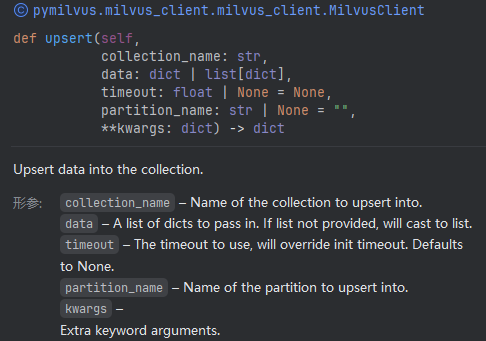

In [ ]:
#插入数据
upsert_res = client.upsert(
    collection_name=collection_name,#collection_name="docs"
    data=data
    #不指定分区，数据自动存入_default
)
print(upsert_res)

In [ ]:
#手动flush，milvus不会第一时间将数据落盘，要看到效果，需要手动flush，将数据刷写到磁盘
client.flush(collection_name=collection_name)

In [ ]:
#查看collection的统计信息
stats = client.get_collection_stats(collection_name=collection_name)
print(stats)

## 嵌入模型后数据的处理
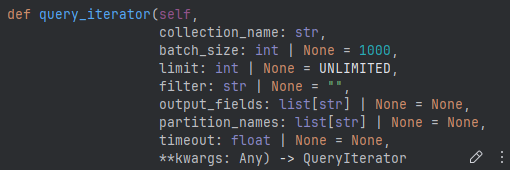

In [ ]:
#扫描数据
iterator = client.query_iterator(
    collection_name=collection_name,
    output_fields=["*"],  # Milvus 的 query_iterator 默认不返回向量字段（因为向量数据量大，传输成本高）。添加 output_fields=["*"] 后，显式要求返回所有字段（包括 vector）
)
i = 0
while True:
    rows=iterator.next()
    if not rows:
        break
    for row in rows:
        print(f"第{i+1}条数据：")
        # print(row)
        print(f"id:{row["id"]},vector={row["vector"][:5]},text={row["text"]},source={row["source"]}")
        i = i + 1
iterator.close()

### 基于主键查询数据

In [ ]:
#基于主键查询数据
res = client.get(
    collection_name=collection_name,
    output_fields=["*"],
    ids=[0,1,2]
)
print(len(res))

for i in res:
    print(f"id:{i["id"]},vector={i["vector"][:5]},text={i["text"]},source={i["source"]}")

### 基于相似度查询数据
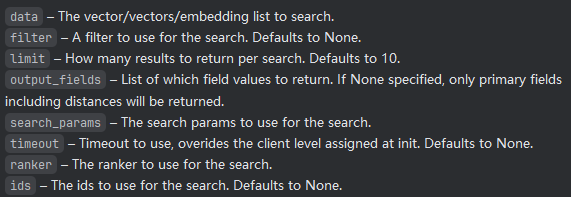

In [59]:
#基于相似度查询数据
query = "什么是向量库？"
#embed_model.embed_query()是接受一个字符串，返回多个向量，而embed_model.embed_documents()接受的是一个字符串列表，返回单个向量
query_vector = embed_model.embed_query(query)

In [62]:
#得到这个向量后，进行相关性匹配
results = client.search(
    collection_name=collection_name,#在哪个collection中查
    data=[query_vector],#要搜索的向量列表，必须用列表包裹（即使只有一个向量）,返回的results也是一个二维列表，因为他支持一次传入多个查询向量做批量搜索，这里的query_vector只是个一维的浮点数列表
    limit=3,#每次搜索返回的结果数量，默认为 10
    output_fields=["id","text","source"]#要返回的字段列表。如果不指定，只返回主键字段和距离值
    #timeout 超时时间，会覆盖客户端初始化时设定的值，默认为 None
    #partition_names 指定collection分区，不加的话搜默认分区
)
# results[0] 是第一个查询向量的结果列表
for res in results[0]:
    print(f"id={res['id']}, distance={res['distance']}, text={res['entity']['text']}")

id=1, distance=0.6608197093009949, text=Milvus 是一个适合 AI 应用的向量数据库
id=3, distance=0.427904337644577, text=Docker Desktop 可以方便地在本地运行 Milvus Standalone
id=2, distance=0.4199245274066925, text=RAG 的核心是先检索相关知识,再让大模型生成答案
